In [2]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score, get_insulation_fixed
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q


NPROC = 8
resolution = 10000
window = 500_000
clr_ = CLR_CONNS(resolution)

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 2
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from ggner_3d import plotting
from ggner_3d.plotting import plot_flanks_start_end_stackup, lineplot_stackup_dict
plotting.update_rcparams()

In [3]:
# pol2

pol2_wt_dict = {
    'wt_nouv_pol2': ["/home/carlos/Clone/ggner-3d/GSM7162996_NCRNAPolIIChIP.primary.ucsc.bw"]}

In [4]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_table_ = [
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv'),
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WT3h_10000bp.csv'),
]

comparisons = [(0,1)]
comparisons_str = ['WTnoUV_WT3h']
sample_names_str = ['WTnoUV', 'WT3h']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_['WTnoUV'].bins()[:], bin_column='idx1') for df in dfs
]

tads = make_tads(dfs[0][['chrom', 'start', 'end']], maxlen=MAXLEN, minlen=MINLEN).sort_values(['chrom', 'start', 'end']).reset_index(drop=True)

WTnoUV_WT3h: Preserved / Increase ::: 1560
WTnoUV_WT3h: Preserved / Decrease ::: 1002


In [5]:
expected_ = {k: get_expected_cis_df(k, resolution_kb=resolution//1000, label='chrom') for k in sample_names_str}
wtnouv_df = assign_domain_score(
                    tads,
                    clr=clr_['WTnoUV'],
                    expected=expected_['WTnoUV'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    rescale_flank=rescale_flank,
                    rescale_size=rescale_size,
                    score_flank=score_flank
                    )

wt3h_df = assign_domain_score(
                    tads,
                    clr=clr_['WT3h'],
                    expected=expected_['WT3h'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    rescale_flank=rescale_flank,
                    rescale_size=rescale_size,
                    score_flank=score_flank
                    )

tads_ds_merged = pd.merge(
    wtnouv_df[['chrom', 'start', 'end', 'domain_score']],
    wt3h_df[['chrom', 'start', 'end', 'domain_score']],
    on=['chrom', 'start', 'end'],
    suffixes=('_WTnoUV', '_WT3h')
)

INFO:coolpuppy:Rescaling with rescale_flank = 2 to 165x165 pixels
INFO:coolpuppy:('chr8', 'chr8'): 108
INFO:coolpuppy:('chr7', 'chr7'): 121
INFO:coolpuppy:('chr5', 'chr5'): 140
INFO:coolpuppy:('chr6', 'chr6'): 143
INFO:coolpuppy:('chr4', 'chr4'): 143
INFO:coolpuppy:('chr3', 'chr3'): 148
INFO:coolpuppy:('chr2', 'chr2'): 175
INFO:coolpuppy:('chr1', 'chr1'): 201
INFO:coolpuppy:('chr9', 'chr9'): 96
INFO:coolpuppy:('chr13', 'chr13'): 66
INFO:coolpuppy:('chr14', 'chr14'): 82
INFO:coolpuppy:('chr10', 'chr10'): 101
INFO:coolpuppy:('chr16', 'chr16'): 53
INFO:coolpuppy:('chr15', 'chr15'): 65
INFO:coolpuppy:('chr12', 'chr12'): 110
INFO:coolpuppy:('chr11', 'chr11'): 121
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/coolpuppy/lib/numutils.py:132: RuntimeWarning: divide by zero encountered in scalar divide
  return central / (top + right) * 2
INFO:coolpuppy:('chr21', 'chr21'): 17
INFO:coolpuppy:('chr17', 'chr17'): 64
INFO:coolpuppy:('chr19', 'chr19'): 52
INFO:coolpuppy:('chr22', 'ch

In [6]:
tads = tads_ds_merged.copy()
tads['ds_diff'] = tads['domain_score_WT3h'] / tads['domain_score_WTnoUV']
tads['ds_diff_Q'] = pd.qcut(tads['ds_diff'], q=4, labels=False) + 1

tads = tads.dropna(subset=['ds_diff_Q']).reset_index(drop=True)
tads['ds_diff_Q'].value_counts()

flank_ratio = 0.25
tads['flank_size'] = (tads['end'] - tads['start']) * flank_ratio
tads['flank_start'] = tads['start'] - tads['flank_size']
tads['flank_end'] = tads['end'] + tads['flank_size']

In [7]:
import importlib
from ggner_3d import bbi_helpers
importlib.reload(bbi_helpers)
from ggner_3d.bbi_helpers import stackup_bw_dict_q

nbins = 150

tads.ds_diff_Q.value_counts()

ds_diff_Q
1.0    560
4.0    559
3.0    559
2.0    559
Name: count, dtype: int64

In [8]:
# q stackups - TADS

pol2_nouv_stackup_tads_q = stackup_bw_dict_q(pol2_wt_dict['wt_nouv_pol2'], tads, q_col='ds_diff_Q', mean_per_q=False, nbins=nbins)

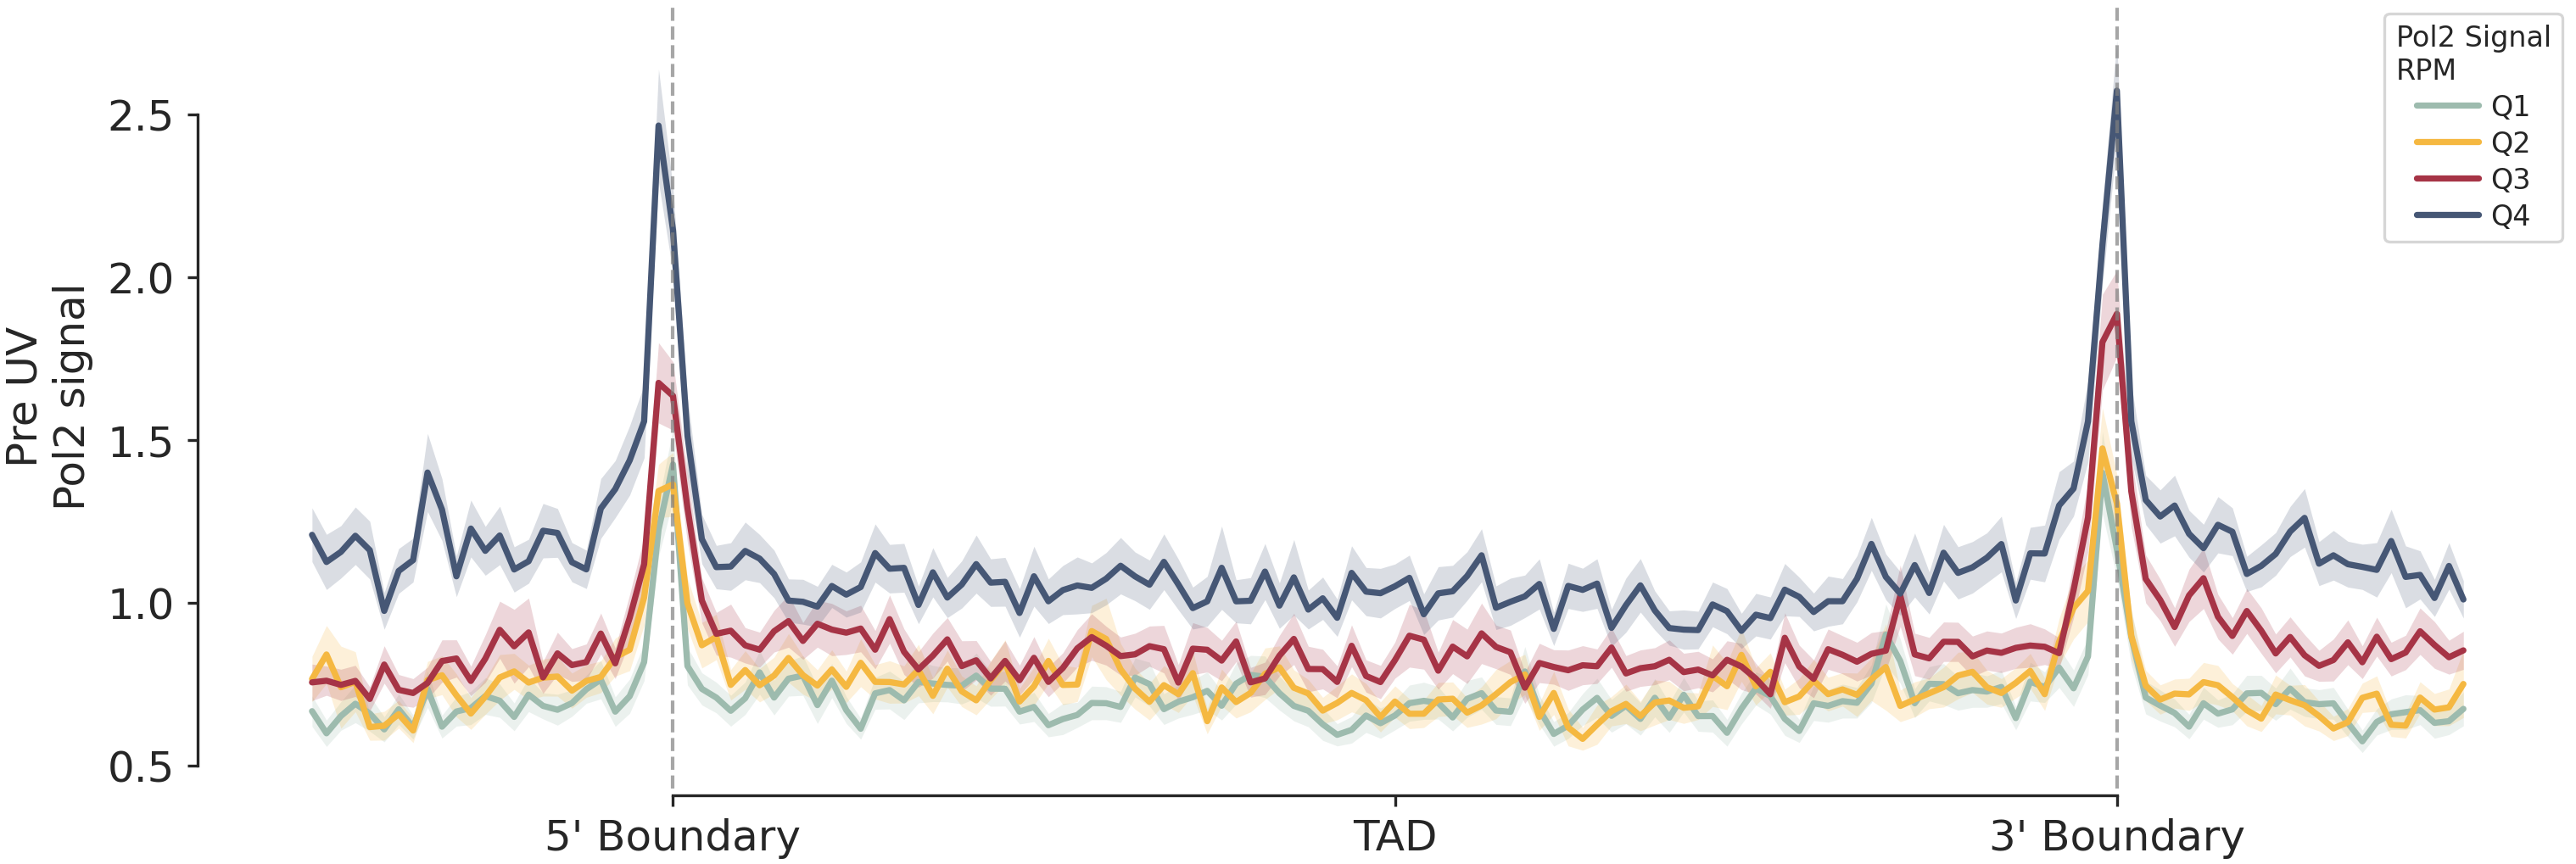

In [9]:
colors = list(reversed(plotting.COLORS))
fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharex='col')

common_params = {
    'plot_kwargs': {'linewidth': 1.75},
    'colors': list(reversed(plotting.COLORS))
}

lineplot_stackup_dict(
    pol2_nouv_stackup_tads_q,
    ax=ax,
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Pol2 Signal\nRPM',
    y_title='Pre UV\nPol2 signal',
    structure_type='TAD',
    **common_params
)

# make all tick labels bigger
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plotting.despine(ax)

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig5/fig5_pol2_u2os.png', bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig5/fig5_pol2_u2os.svg', bbox_inches='tight')